<a href="https://colab.research.google.com/github/yassineghoulbhiri/stock-market-dashboard/blob/main/stock_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries ready ✅")

Libraries ready ✅


In [5]:
tickers = ["AAPL", "MSFT", "AMZN", "GOOGL"]

data = yf.download(tickers, start="2022-01-01", end="2026-07-29")["Close"]

data.head()

/tmp/ipykernel_2608/2541419738.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2022-01-01", end="2026-07-29")["Close"]
[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2022-01-03,177.939728,170.404495,143.717133,322.462372
2022-01-04,175.681396,167.522003,143.130341,316.933075
2022-01-05,171.008270,164.356995,136.564041,304.766663
2022-01-06,168.153580,163.253998,136.536789,302.358459
2022-01-07,168.319748,162.554001,135.812729,302.512573


In [6]:
returns = data.pct_change()

returns.head()

/tmp/ipykernel_2608/3456711179.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change()


Ticker,AAPL,AMZN,GOOGL,MSFT
Date,,,,
2022-01-03,NaN,NaN,NaN,NaN
2022-01-04,-0.012692,-0.016916,-0.004083,-0.017147
2022-01-05,-0.026600,-0.018893,-0.045876,-0.038388
2022-01-06,-0.016693,-0.006711,-0.000200,-0.007902
2022-01-07,0.000988,-0.004288,-0.005303,0.000510


In [7]:
data["AAPL_MA20"] = data["AAPL"].rolling(window=20).mean()
data["AAPL_MA50"] = data["AAPL"].rolling(window=50).mean()

data[["AAPL", "AAPL_MA20", "AAPL_MA50"]].tail()

Ticker,AAPL,AAPL_MA20,AAPL_MA50
Date,,,
2026-07-22,325.890015,310.062999,304.8874
2026-07-23,321.660004,311.492000,305.4670
2026-07-24,333.019989,314.385500,306.2314
2026-07-27,336.910004,317.042000,306.9922
2026-07-28,NaN,NaN,NaN


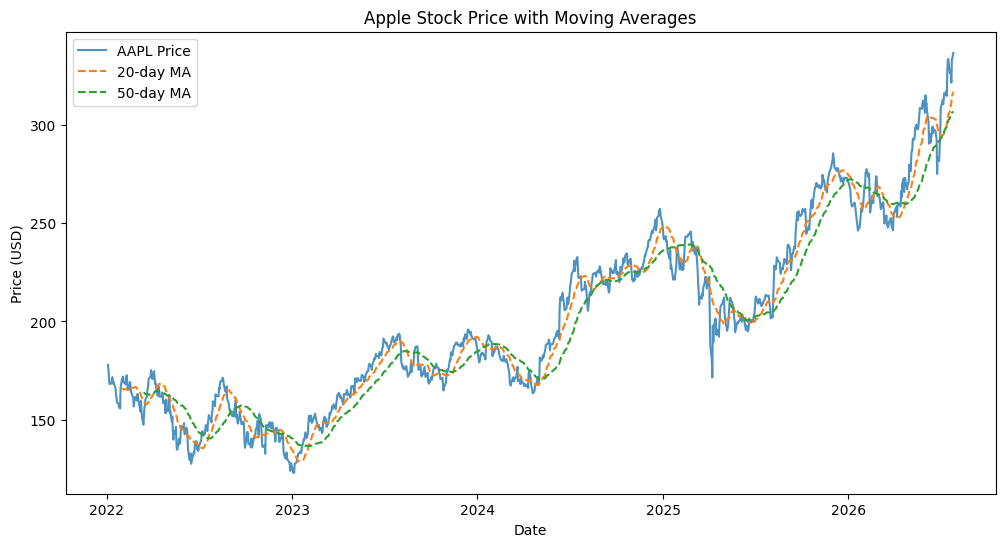

In [8]:
plt.figure(figsize=(12,6))
plt.plot(data["AAPL"], label="AAPL Price", alpha=0.8)
plt.plot(data["AAPL_MA20"], label="20-day MA", linestyle="--")
plt.plot(data["AAPL_MA50"], label="50-day MA", linestyle="--")
plt.title("Apple Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

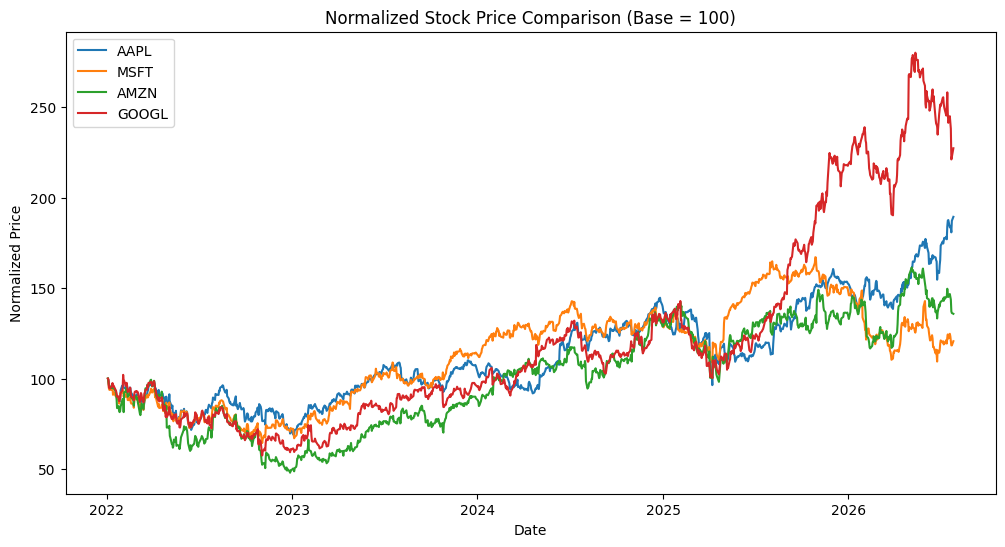

In [9]:
# Normalize prices so we can compare them fairly (all starting at 100)
normalized = data[tickers] / data[tickers].iloc[0] * 100

plt.figure(figsize=(12,6))
for ticker in tickers:
    plt.plot(normalized[ticker], label=ticker)
plt.title("Normalized Stock Price Comparison (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()
plt.show()

<Figure size 1200x600 with 0 Axes>

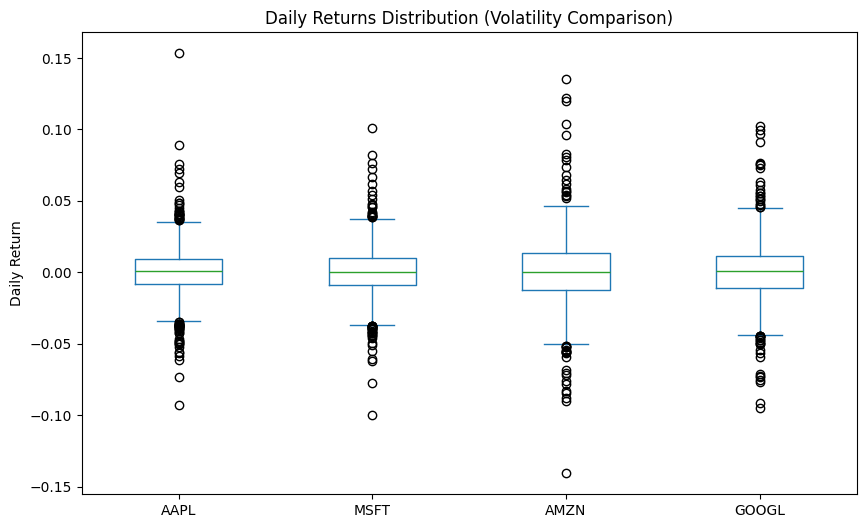

In [10]:
plt.figure(figsize=(12,6))
returns[tickers].plot(kind="box", figsize=(10,6))
plt.title("Daily Returns Distribution (Volatility Comparison)")
plt.ylabel("Daily Return")
plt.show()